# 🌐 Google Drive connection

In [4]:
from google.colab import drive

# drive.mount('/content/drive')
# current_dir = "/content/drive/MyDrive/an2dl-2"
# %cd $current_dir
# data_dir = "."

!gdown --folder --remaining-ok "https://drive.google.com/drive/folders/1oIQ0wakp0o_qZ1Yz_UpiBZnzZBzFeLJe?usp=sharing"


!gdown  1Eyllp0o0NyqXqOc94kj4ayPpsRAuT52u
!gdown  1x7lTtRZkYZjX2cwCQvOku1gtEeNloMs3

Downloading...
From (original): https://drive.google.com/uc?id=1Eyllp0o0NyqXqOc94kj4ayPpsRAuT52u
From (redirected): https://drive.google.com/uc?id=1Eyllp0o0NyqXqOc94kj4ayPpsRAuT52u&confirm=t&uuid=1b72077f-8e18-4e4e-86bd-f6dc8efc7066
To: /content/test/train_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK (1).npz
100% 433M/433M [00:03<00:00, 142MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1x7lTtRZkYZjX2cwCQvOku1gtEeNloMs3
From (redirected): https://drive.google.com/uc?id=1x7lTtRZkYZjX2cwCQvOku1gtEeNloMs3&confirm=t&uuid=0a6b5e8c-c389-48d9-a755-d620388abb52
To: /content/test/test_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK (1).npz
100% 340M/340M [00:02<00:00, 146MB/s]


# ⚙️ **Libraries Import**

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import v2 as transforms
from torchvision.datasets import VisionDataset
from torch.utils.data import TensorDataset, DataLoader, Dataset
from sklearn.model_selection import GroupShuffleSplit

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p Models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
from datetime import datetime

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.9.0+cu126
Device: cuda


In [ ]:
# ============================================================
# ADVICE 11/12: Lightweight Texture Augmentation
# Uses masks to condition texture variations
# ============================================================
from scipy.ndimage import gaussian_filter

class LightweightTextureAugmenter:
    """
    Lightweight texture augmentation conditioned on mask regions.
    Simulates H&E stain variations and texture changes within tissue areas.
    """
    def __init__(self, probability=0.3):
        self.probability = probability

    def __call__(self, image: np.ndarray, mask: np.ndarray) -> np.ndarray:
        """
        Args:
            image: numpy array (C, H, W) RGB, values 0-1 (your format)
            mask: numpy array (H, W) binary mask
        Returns:
            augmented image (C, H, W)
        """
        if np.random.random() > self.probability:
            return image

        # Convert from (C, H, W) to (H, W, C) for processing
        image = np.transpose(image, (1, 2, 0)).copy()  # (H, W, C)
        image = (image * 255).astype(np.float32)  # Scale to 0-255

        mask_bool = mask > 0.5
        mask_3d = np.stack([mask_bool] * 3, axis=-1)

        augmentation = np.random.choice([
            'color_shift', 'texture_noise', 'stain_variation', 'contrast_shift'
        ])

        if augmentation == 'color_shift':
            # Shift H&E stain colors slightly within masked region
            shift = np.random.uniform(-15, 15, size=(3,))
            shifted = image.copy()
            for c in range(3):
                shifted[:, :, c] = np.where(
                    mask_bool,
                    np.clip(image[:, :, c] + shift[c], 0, 255),
                    image[:, :, c]
                )
            image = shifted

        elif augmentation == 'texture_noise':
            # Add structured noise to simulate texture variation
            noise = np.random.normal(0, 8, image.shape).astype(np.float32)
            noise = gaussian_filter(noise, sigma=1.5)
            image = np.where(mask_3d, np.clip(image + noise, 0, 255), image)

        elif augmentation == 'stain_variation':
            # Simulate H&E stain intensity variation
            h_factor = np.random.uniform(0.9, 1.1)  # Hematoxylin (blue/purple)
            e_factor = np.random.uniform(0.9, 1.1)  # Eosin (pink)

            modified = image.copy()
            # Blue channel for Hematoxylin
            modified[:, :, 2] = np.where(
                mask_bool,
                np.clip(modified[:, :, 2] * h_factor, 0, 255),
                modified[:, :, 2]
            )
            # Red channel for Eosin
            modified[:, :, 0] = np.where(
                mask_bool,
                np.clip(modified[:, :, 0] * e_factor, 0, 255),
                modified[:, :, 0]
            )
            # Green channel
            modified[:, :, 1] = np.where(
                mask_bool,
                np.clip(modified[:, :, 1] * e_factor * 0.95, 0, 255),
                modified[:, :, 1]
            )
            image = modified

        elif augmentation == 'contrast_shift':
            # Local contrast adjustment within mask
            factor = np.random.uniform(0.85, 1.15)
            masked_pixels = image[mask_3d].reshape(-1, 3)
            if len(masked_pixels) > 0:
                mean_val = masked_pixels.mean()
                modified = mean_val + factor * (image - mean_val)
                image = np.where(mask_3d, np.clip(modified, 0, 255), image)

        # Convert back to (C, H, W) and scale to 0-1
        image = (image / 255.0).astype(np.float32)
        image = np.transpose(image, (2, 0, 1))  # (C, H, W)

        return image

In [ ]:
# ============================================================
# ADVICE 13/12: Histopathology-Specific Pretrained Backbone
# Option 1: Lunit DINO (ViT pretrained on pathology)
# Option 2: REMEDIS/Path (if available via timm)
# ============================================================

!pip install timm -q

import timm

def load_pathology_backbone(backbone_type='lunit_dino'):
    """
    Load pathology-specific pretrained backbone.

    Options:
    - 'lunit_dino': Lunit's DINO ViT-S pretrained on pathology (via HuggingFace)
    - 'phikon': Owkin's Phikon (ViT-B pretrained on TCGA)
    - 'imagenet_vit': Fallback to ImageNet ViT-S
    - 'efficientnet_b2': Original EfficientNet-B2
    """

    if backbone_type == 'lunit_dino':
        # Lunit DINO - ViT-Small pretrained on pathology images
        # Available directly through timm with HuggingFace integration
        try:
            model = timm.create_model(
                'hf_hub:1aurent/vit_small_patch16_224.lunit_dino',
                pretrained=True,
                num_classes=0  # Remove classification head
            )
            rgb_features = 384  # ViT-S output dim
            print("✅ Lunit DINO (ViT-S pathology) loaded successfully!")
        except Exception as e:
            print(f"⚠️ Lunit DINO failed: {e}")
            print("   Falling back to ImageNet ViT-S")
            model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)
            rgb_features = 384

    elif backbone_type == 'phikon':
        # Owkin's Phikon - ViT-B pretrained on TCGA pathology
        try:
            model = timm.create_model(
                'hf_hub:owkin/phikon',
                pretrained=True,
                num_classes=0
            )
            rgb_features = 768  # ViT-B output dim
            print("✅ Phikon (ViT-B pathology) loaded successfully!")
        except Exception as e:
            print(f"⚠️ Phikon failed: {e}")
            model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
            rgb_features = 768

    elif backbone_type == 'imagenet_vit':
        # ImageNet pretrained ViT-S (baseline comparison)
        model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=0)
        rgb_features = 384
        print("✅ ImageNet ViT-S loaded")

    elif backbone_type == 'efficientnet_b2':
        # Original EfficientNet-B2
        model = torchvision.models.efficientnet_b2(
            weights=torchvision.models.EfficientNet_B2_Weights.DEFAULT
        )
        rgb_features = model.classifier[1].in_features  # 1408
        model.classifier = nn.Identity()
        print("✅ EfficientNet-B2 (ImageNet) loaded")

    else:
        raise ValueError(f"Unknown backbone: {backbone_type}")

    return model, rgb_features

# 📊 Load Data (WITH MASKS)

In [ ]:
# ============================================================
# MODIFIED: Load the processed dataset WITH MASKS
# ============================================================

def load_processed_data(filepath):
    """Load previously saved dataset WITH MASKS."""
    print(f"Loading processed data from {filepath}...")
    data = np.load(filepath, allow_pickle=True)

    X = data['X']
    X_masks = data['X_masks']  # ✅ NEW: Load masks
    img_indices = data['img_indices']
    filenames = data['filenames']

    if 'y' in data and 'class_names' in data:
        y = data['y']
        class_names = data['class_names'].tolist()
        return (X, X_masks, y, img_indices, filenames), class_names
    else:
        return (X, X_masks, img_indices, filenames)

In [ ]:
# Load training data WITH MASKS
(X_train, X_masks_train, y_train, img_indices_train, train_filenames), class_names = load_processed_data(
    "train_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz"
)

print(f"X_train shape: {X_train.shape}")
print(f"X_masks_train shape: {X_masks_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Classes: {class_names}")

Loading processed data from train_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz...
X_train shape: (3302, 3, 224, 224)
X_masks_train shape: (3302, 224, 224)
y_train shape: (3302,)
Classes: ['HER2(+)', 'Luminal A', 'Luminal B', 'Triple negative']


In [ ]:
# Load test data WITH MASKS
(X_test, X_masks_test, img_indices_test, test_filenames) = load_processed_data(
    "test_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz"
)

print(f"X_test shape: {X_test.shape}")
print(f"X_masks_test shape: {X_masks_test.shape}")

Loading processed data from test_data_patches_no_outliers_no_duplicates_size224x224_maskmin005_WITHMASK.npz...
X_test shape: (2563, 3, 224, 224)
X_masks_test shape: (2563, 224, 224)


In [ ]:
print("Unique image indices (test):", np.unique(img_indices_test).size)

Unique image indices (test): 477


In [ ]:
# Define the input shape and number of classes
input_shape = (3, 224, 224)
num_classes = len(class_names)

print("Input Shape:", input_shape)
print("Number of Classes:", num_classes)

Input Shape: (3, 224, 224)
Number of Classes: 4


# 🏋️ Model Training

In [ ]:
# ============================================================
# MODIFIED: Split function that includes masks
# ============================================================

def split_train_val_by_image_stratified(X, X_masks, y, img_indices, val_size=0.2, random_state=42):
    """Split data AND masks together by image."""

    img_indices = np.array(img_indices)
    y = np.array(y)

    # Extract unique image IDs
    unique_imgs = np.unique(img_indices)

    # Extract one label per image
    img_to_label = {img: y[np.where(img_indices == img)[0][0]] for img in unique_imgs}
    unique_labels = np.array([img_to_label[img] for img in unique_imgs])

    # Stratified split ON IMAGES
    train_imgs, val_imgs = train_test_split(
        unique_imgs,
        test_size=val_size,
        random_state=random_state,
        stratify=unique_labels,
    )

    train_imgs = set(train_imgs)
    val_imgs = set(val_imgs)

    # Select patches belonging to the chosen images
    train_mask = np.array([idx in train_imgs for idx in img_indices])
    val_mask = np.array([idx in val_imgs for idx in img_indices])

    # Split ALL arrays including masks
    X_tr = X[train_mask]
    X_masks_tr = X_masks[train_mask]  # ✅ Split masks too
    y_tr = y[train_mask]
    idx_tr = img_indices[train_mask]

    X_val = X[val_mask]
    X_masks_val = X_masks[val_mask]  # ✅ Split masks too
    y_val = y[val_mask]
    idx_val = img_indices[val_mask]

    return (X_tr, X_masks_tr, y_tr, idx_tr), (X_val, X_masks_val, y_val, idx_val)

In [ ]:
# Split into train and validation sets BY IMAGE (including masks)
(X_train_split, X_masks_train_split, y_train_split, idx_tr), \
(X_val_split, X_masks_val_split, y_val_split, idx_val) = split_train_val_by_image_stratified(
    X_train, X_masks_train, y_train, img_indices_train, val_size=0.2
)

In [ ]:
# Print shapes of the datasets
print(f"X_train shape: {X_train_split.shape}, X_masks_train shape: {X_masks_train_split.shape}, y_train shape: {y_train_split.shape}")
print(f"X_val shape: {X_val_split.shape}, X_masks_val shape: {X_masks_val_split.shape}, y_val shape: {y_val_split.shape}")

X_train shape: (2630, 3, 224, 224), X_masks_train shape: (2630, 224, 224), y_train shape: (2630,)
X_val shape: (672, 3, 224, 224), X_masks_val shape: (672, 224, 224), y_val shape: (672,)


In [ ]:
# Define the batch size
BATCH_SIZE = 64

In [ ]:
# ImageNet normalization statistics
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

GLOBAL_MEAN_COLOR = (178, 175, 174)


class AutoAugmentStrategy:
    """Augmentation strategy for training."""
    def __init__(self, strategy='randaugment', global_mean_color=GLOBAL_MEAN_COLOR, **kwargs):
        self.strategy = strategy
        self.global_mean_color = global_mean_color
        self.transform = self._build_transform(**kwargs)

    def _build_transform(self, **kwargs):
        fill = self.global_mean_color

        if self.strategy == 'randaugment':
            return transforms.RandAugment(
                num_ops=kwargs.get('num_ops', 2),
                magnitude=kwargs.get('magnitude', 9),
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=fill
            )
        elif self.strategy == 'trivialaugment':
            return transforms.TrivialAugmentWide(
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=fill
            )
        elif self.strategy == 'autoaugment':
            return transforms.AutoAugment(
                policy=transforms.AutoAugmentPolicy.IMAGENET,
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=fill
            )
        elif self.strategy == 'custom':
            return transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomAffine(
                    degrees=(-180, 180),
                    translate=(0.1, 0.1),
                    scale=(0.8, 1.2),
                    interpolation=transforms.InterpolationMode.BILINEAR,
                    fill=fill
                ),
                transforms.ColorJitter(brightness=0.1, contrast=0.1),
            ])
        elif self.strategy in (None, 'none'):
            return lambda x: x  # identity
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

    def __call__(self, img):
        return self.transform(img)

In [ ]:
# ============================================================
# MODIFIED: Dataset for Dual-Path Model with Generative Augmentation
# ADVICE 11/12: Generative Mask Conditioning
# ============================================================

class OgresDatasetDualPath(Dataset):
    """
    Dataset for dual-path model that returns (image, mask, label).
    Supports augmentation expansion AND generative texture augmentation.
    """

    def __init__(self, images, masks, labels,
                 augmentation_strategy='custom',
                 num_augmentations=4,
                 normalize_imagenet=True,
                 use_texture_aug=False,      # NEW: Enable texture augmentation
                 texture_aug_prob=0.3):       # NEW: Probability of applying
        """
        Args:
            images: (N, C, H, W) RGB images in [0, 1]
            masks: (N, H, W) binary masks in [0, 1]
            labels: (N,) class labels
            use_texture_aug: Whether to use generative texture augmentation
            texture_aug_prob: Probability of applying texture augmentation
        """
        self.images = torch.from_numpy(images).float()
        self.masks = torch.from_numpy(masks).float()
        self.labels = torch.from_numpy(labels).long()
        self.num_augmentations = num_augmentations

        # Setup augmentation
        if augmentation_strategy not in [None, 'none']:
            self.augment = AutoAugmentStrategy(strategy=augmentation_strategy)
            self.use_augmentation = True
        else:
            self.augment = None
            self.use_augmentation = False

        # NEW: Setup texture augmentation (ADVICE 11/12)
        self.use_texture_aug = use_texture_aug
        if use_texture_aug:
            self.texture_augmenter = LightweightTextureAugmenter(probability=texture_aug_prob)

        # ImageNet normalization
        self.normalize = transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        ) if normalize_imagenet else None

    def __len__(self):
        if self.use_augmentation:
            return len(self.images) * (self.num_augmentations + 1)
        return len(self.images)

    def __getitem__(self, idx):
        base_idx = idx % len(self.images)
        is_original = idx < len(self.images)

        image = self.images[base_idx].clone()  # (C, H, W)
        mask = self.masks[base_idx].clone()    # (H, W)
        label = self.labels[base_idx]

        # Ensure mask has channel dimension: (H, W) -> (1, H, W)
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        # Apply augmentation if not original sample
        if not is_original and self.augment is not None:
            # NEW: Apply texture augmentation BEFORE color augmentation
            if self.use_texture_aug:
                img_np = image.numpy()  # (C, H, W)
                mask_np = mask.squeeze(0).numpy()  # (H, W)
                img_np = self.texture_augmenter(img_np, mask_np)
                image = torch.from_numpy(img_np).float()

            # Convert image to PIL for standard augmentation
            pil_img = transforms.ToPILImage()(torch.clamp(image, 0, 1))
            pil_img = pil_img.convert("RGB")
            aug_img = self.augment(pil_img)
            image = transforms.ToTensor()(aug_img)

        # Normalize image (not mask)
        if self.normalize is not None:
            image = self.normalize(image)

        # Ensure mask is binary [0, 1]
        mask = (mask > 0.5).float()

        return image, mask, label

In [ ]:
# Mix up for data augmentation: to apply in the training loop
def apply_mixup(inputs, targets, alpha=0.1):
    lam = np.random.beta(alpha, alpha)
    batch_size = inputs.size(0)
    index = torch.randperm(batch_size, device=inputs.device)

    mixed_inputs = lam * inputs + (1 - lam) * inputs[index]
    targets_a, targets_b = targets, targets[index]
    return mixed_inputs, targets_a, targets_b, lam

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    """Create a PyTorch DataLoader with optimized settings."""
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

##  🧮 **Network Parameters**

In [ ]:
# Training parameters
LEARNING_RATE = 1e-3
LEARNING_RATE_FT = 1e-4
EPOCHS = 100
PATIENCE = 20

DROPOUT_RATE = 0.2  # Increased from 0.2
L2 = 0.01
LABEL_SMOOTHING = 0.05  # Increased from 0.05

# Set up loss function with class weights
class_counts = np.bincount(y_train_split)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(device),
    label_smoothing=LABEL_SMOOTHING
)

# Print the defined parameters
print("Epochs:", EPOCHS)
print("Batch Size:", BATCH_SIZE)
print("Learning Rate:", LEARNING_RATE)
print("Dropout Rate:", DROPOUT_RATE)
print("Patience:", PATIENCE)
print("Class weights:", class_weights)

Epochs: 100
Batch Size: 64
Learning Rate: 0.001
Dropout Rate: 0.2
Patience: 20
Class weights: [0.19044627 0.1766947  0.1359475  0.49691153]


##  🧠 **Training Functions for Dual-Path Model**

In [ ]:
# ============================================================
# NEW: Training functions for Dual-Path model
# ============================================================

def train_one_epoch_dual(model, train_loader, criterion, optimizer, scaler, device):
    """Train for one epoch - Dual-Path model version."""
    model.train()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    for images, masks, targets in train_loader:  # ✅ Now unpacks 3 items
        images = images.to(device)
        masks = masks.to(device)
        targets = targets.to(device)

        images_mixed, targets_a, targets_b, lam = apply_mixup(images, targets, alpha=0.2)


        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(images_mixed, masks)  # Use mixed images, original masks
            # ✅ MixUp loss
            loss = lam * criterion(logits, targets_a) + (1 - lam) * criterion(logits, targets_b)


        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = accuracy_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions)
    )
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch_dual(model, val_loader, criterion, device):
    """Validate for one epoch - Dual-Path model version."""
    model.eval()

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for images, masks, targets in val_loader:  # ✅ Now unpacks 3 items
            images = images.to(device)
            masks = masks.to(device)
            targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(images, masks)  # ✅ Pass both image and mask
                loss = criterion(logits, targets)

            running_loss += loss.item() * images.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_acc = accuracy_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions)
    )
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_acc, epoch_f1


def fit_dual(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device, scheduler=None,
             patience=0, evaluation_metric="val_f1", mode='max',
             restore_best_weights=True, writer=None, verbose=1, experiment_name=""):
    """Training loop for Dual-Path model."""

    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    for epoch in range(1, epochs + 1):
        # ✅ Use dual training functions
        train_loss, train_acc, train_f1 = train_one_epoch_dual(
            model, train_loader, criterion, optimizer, scaler, device
        )

        val_loss, val_acc, val_f1 = validate_one_epoch_dual(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step(val_f1)

        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_acc'].append(train_acc)
        training_history['val_acc'].append(val_acc)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        if writer is not None:
            writer.add_scalar('Loss/Training', train_loss, epoch)
            writer.add_scalar('Loss/Validation', val_loss, epoch)
            writer.add_scalar('Accuracy/Training', train_acc, epoch)
            writer.add_scalar('Accuracy/Validation', val_acc, epoch)
            writer.add_scalar('F1/Training', train_f1, epoch)
            writer.add_scalar('F1/Validation', val_f1, epoch)

        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}, F1={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, Acc={val_acc:.4f}, F1={val_f1:.4f}")

        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "Models/" + experiment_name + '_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("Models/" + experiment_name + '_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    if patience == 0:
        torch.save(model.state_dict(), "Models/" + experiment_name + '_model.pt')

    if writer is not None:
        writer.close()

    return model, training_history

## 🛠️ **Dual-Path Model Architecture**

In [ ]:
# ============================================================
# Dual-Path Model with Pathology-Specific Backbone
# ============================================================

class DualPathHistoNet(nn.Module):
    """
    Two-branch architecture with histopathology-specific backbone.
    """

    def __init__(self, num_classes, dropout_rate=0.5, backbone_type='lunit_dino',
                 freeze_rgb_backbone=False):
        super().__init__()

        self.backbone_type = backbone_type

        # ===== Branch 1: Pathology-Specific Encoder =====
        self.rgb_backbone, rgb_features = load_pathology_backbone(backbone_type)

        if freeze_rgb_backbone:
            for param in self.rgb_backbone.parameters():
                param.requires_grad = False

        # ===== Branch 2: Mask Geometry Encoder (unchanged) =====
        self.mask_encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        mask_features = 256

        # ===== Fusion Layer =====
        combined_features = rgb_features + mask_features

        self.fusion_classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(combined_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

        self.rgb_features = rgb_features
        self.mask_features = mask_features

    def forward(self, rgb_image, mask):
        # Branch 1: RGB features (timm models have forward_features)
        if hasattr(self.rgb_backbone, 'forward_features'):
            rgb_features = self.rgb_backbone.forward_features(rgb_image)
            # Handle different output shapes
            if rgb_features.dim() == 3:  # (B, num_patches, features)
                rgb_features = rgb_features.mean(dim=1)  # Global avg pool
            elif rgb_features.dim() == 4:  # (B, C, H, W)
                rgb_features = rgb_features.mean(dim=[2, 3])
        else:
            rgb_features = self.rgb_backbone(rgb_image)

        # Branch 2: Mask features
        mask_features = self.mask_encoder(mask)

        # Fusion
        combined = torch.cat([rgb_features, mask_features], dim=1)
        output = self.fusion_classifier(combined)
        return output


# Alias for compatibility
DualPathEfficientNet = DualPathHistoNet

In [ ]:
!pip install torch-optimizer -q

In [ ]:
import torch_optimizer as optim

# ============================================================
# Choose backbone: 'lunit_dino', 'phikon', 'efficientnet_b2'
# ============================================================

BACKBONE_TYPE = 'lunit_dino'  # <-- Pathology-specific!

ft_model = DualPathHistoNet(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    backbone_type=BACKBONE_TYPE,
    freeze_rgb_backbone=False
).to(device)

# ===== FREEZE ALL FIRST =====
for p in ft_model.parameters():
    p.requires_grad = False

# ===== UNFREEZE: Fusion classifier =====
for p in ft_model.fusion_classifier.parameters():
    p.requires_grad = True

# ===== UNFREEZE: Mask encoder =====
for p in ft_model.mask_encoder.parameters():
    p.requires_grad = True

# ===== UNFREEZE: Last layers of backbone =====
if 'vit' in BACKBONE_TYPE or 'dino' in BACKBONE_TYPE or 'phikon' in BACKBONE_TYPE:
    # ViT: unfreeze last 2-4 transformer blocks
    for name, p in ft_model.rgb_backbone.named_parameters():
        # Unfreeze last blocks (blocks.10, blocks.11 for ViT-S/12 blocks)
        if any(f'blocks.{i}' in name for i in [9, 10, 11]):
            p.requires_grad = True
        # Also unfreeze norm layer
        if 'norm' in name and 'blocks' not in name:
            p.requires_grad = True
elif BACKBONE_TYPE == 'efficientnet_b2':
    for p in ft_model.rgb_backbone.features[7].parameters():
        p.requires_grad = True
    for p in ft_model.rgb_backbone.features[8].parameters():
        p.requires_grad = True

# ===== PARAM GROUPS =====
rgb_params = []
mask_params = []
fusion_params = []

for name, param in ft_model.named_parameters():
    if not param.requires_grad:
        continue
    if 'rgb_backbone' in name:
        rgb_params.append(param)
    elif 'mask_encoder' in name:
        mask_params.append(param)
    elif 'fusion_classifier' in name:
        fusion_params.append(param)

# ===== OPTIMIZER =====
optimizer = optim.Ranger(
    [
        {'params': rgb_params, 'lr': LEARNING_RATE_FT},
        {'params': mask_params, 'lr': LEARNING_RATE},
        {'params': fusion_params, 'lr': LEARNING_RATE},
    ],
    weight_decay=L2
)

trainable_params = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in ft_model.parameters())

print(f"Backbone: {BACKBONE_TYPE}")
print(f"RGB feature dim: {ft_model.rgb_features}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

✅ Lunit DINO (ViT-S pathology) loaded successfully!
Backbone: lunit_dino
RGB feature dim: 384
Total parameters: 22,385,988
Trainable parameters: 6,044,484


In [ ]:
# Create datasets for Dual-Path model
print("\nCreating training dataset with augmentation...")
train_ds = OgresDatasetDualPath(
    X_train_split,
    X_masks_train_split,
    y_train_split,
    augmentation_strategy='custom',  # 'trivialaugment', 'randaugment', 'autoaugment', 'custom'
    num_augmentations=4,
    normalize_imagenet=True,
    use_texture_aug=True,      # ✅ Enable ADVICE 11/12
    texture_aug_prob=0.3       # Apply to 30% of augmented samples
)

print("Creating validation dataset (no augmentation)...")
val_ds = OgresDatasetDualPath(
    X_val_split,
    X_masks_val_split,
    y_val_split,
    num_augmentations=0,
    augmentation_strategy=None,  # No augmentation for validation!
    normalize_imagenet=True,
    use_texture_aug=False        # ✅ Never augment validation
)

# Create DataLoaders
train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = make_loader(val_ds, BATCH_SIZE, shuffle=False, drop_last=False)

print(f"Train dataset size: {len(train_ds)}")
print(f"Val dataset size: {len(val_ds)}")
print("Datasets ready for training!\n")


Creating training dataset with augmentation...
Creating validation dataset (no augmentation)...
Train dataset size: 13150
Val dataset size: 672
Datasets ready for training!



In [ ]:
# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=5,
    threshold=1e-3,
    threshold_mode='abs',
    cooldown=1,
    min_lr=1e-6,
)

# Mixed precision scaler
scaler = torch.amp.GradScaler()

# TensorBoard writer
experiment_name = "dual_path_efficientnet_b2"
writer = SummaryWriter(f"{logs_dir}/{experiment_name}")

In [ ]:
%%time
# Train the Dual-Path model
ft_model, ft_history = fit_dual(
    model=ft_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    scheduler=scheduler,
    device=device,
    writer=writer,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    evaluation_metric="val_f1",
)

final_val_acc = round(max(ft_history['val_acc']) * 100, 2)
print(f'Final validation accuracy: {final_val_acc}%')
final_val_F1 = round(max(ft_history['val_f1']) * 100, 2)
print(f'Final validation F1: {final_val_F1}%')

Training 100 epochs...
Epoch   1/100 | Train: Loss=1.3203, Acc=0.3230, F1=0.3324 | Val: Loss=1.4253, Acc=0.2619, F1=0.2627
Epoch   2/100 | Train: Loss=1.1574, Acc=0.3816, F1=0.3862 | Val: Loss=1.5747, Acc=0.3021, F1=0.2818
Epoch   3/100 | Train: Loss=1.0404, Acc=0.4671, F1=0.4723 | Val: Loss=1.6441, Acc=0.3080, F1=0.3005
Epoch   4/100 | Train: Loss=0.9057, Acc=0.5618, F1=0.5650 | Val: Loss=1.6958, Acc=0.3676, F1=0.3538
Epoch   5/100 | Train: Loss=0.8539, Acc=0.5683, F1=0.5724 | Val: Loss=1.7717, Acc=0.3155, F1=0.3146
Epoch   6/100 | Train: Loss=0.7735, Acc=0.5698, F1=0.5724 | Val: Loss=1.8087, Acc=0.3006, F1=0.2940
Epoch   7/100 | Train: Loss=0.7593, Acc=0.6074, F1=0.6104 | Val: Loss=1.7932, Acc=0.3199, F1=0.3086
Epoch   8/100 | Train: Loss=0.6762, Acc=0.6292, F1=0.6316 | Val: Loss=1.9157, Acc=0.3065, F1=0.2802
Epoch   9/100 | Train: Loss=0.6597, Acc=0.6229, F1=0.6249 | Val: Loss=1.7748, Acc=0.3482, F1=0.3497
Epoch  10/100 | Train: Loss=0.6537, Acc=0.6621, F1=0.6637 | Val: Loss=1.8508,

## 📈 Training History

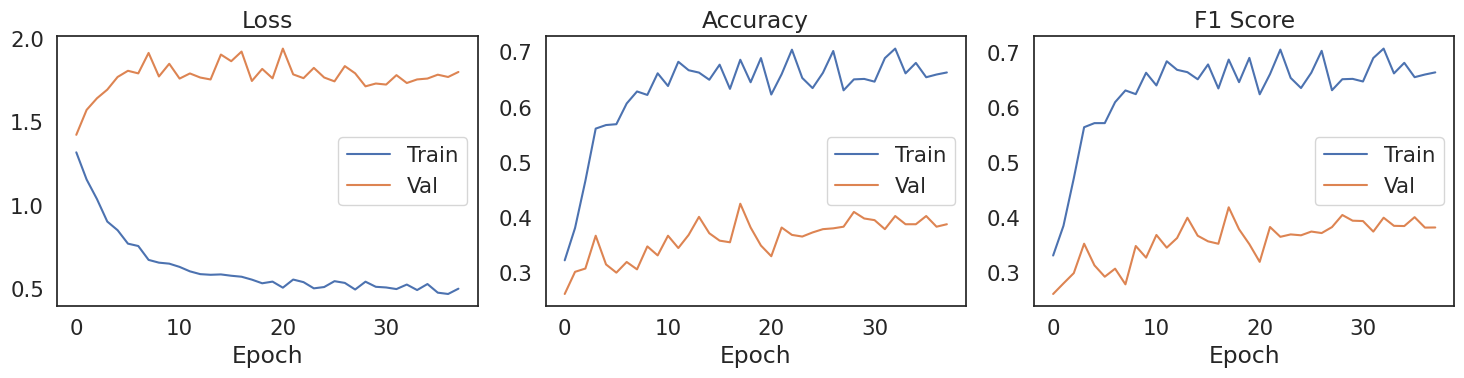

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(ft_history['train_loss'], label='Train')
axes[0].plot(ft_history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(ft_history['train_acc'], label='Train')
axes[1].plot(ft_history['val_acc'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# F1 Score
axes[2].plot(ft_history['train_f1'], label='Train')
axes[2].plot(ft_history['val_f1'], label='Val')
axes[2].set_title('F1 Score')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

# 🔮 Inference and Aggregation

In [ ]:
def aggregate_patch_predictions_weighted(all_logits, all_img_indices, patch_scores=None, method='mean'):
    """
    Aggregate patch-level predictions to image-level.

    Methods:
    - 'mean': Average probabilities
    - 'weighted_mean': Weighted average by patch_scores
    - 'max_confidence': Take prediction with highest confidence
    - 'majority_vote': Most common predicted class
    """
    all_probs = torch.softmax(all_logits, dim=1).detach().cpu().numpy()
    img_indices = np.array(all_img_indices)

    img_to_probs = {}
    img_to_scores = {}

    for i, (prob, idx) in enumerate(zip(all_probs, img_indices)):
        if idx not in img_to_probs:
            img_to_probs[idx] = []
            img_to_scores[idx] = []
        img_to_probs[idx].append(prob)
        if patch_scores is not None:
            img_to_scores[idx].append(patch_scores[i])

    img_ids = sorted(img_to_probs.keys())
    img_probs = []

    for idx in img_ids:
        probs = np.stack(img_to_probs[idx], axis=0)

        if method == 'mean':
            avg_prob = probs.mean(axis=0)
        elif method == 'weighted_mean':
            if patch_scores is None:
                raise ValueError("patch_scores must be provided for 'weighted_mean' method")
            scores = np.array(img_to_scores[idx])
            avg_prob = (probs * scores[:, None]).sum(axis=0) / scores.sum()
        elif method == 'max_confidence':
            max_conf_idx = probs.max(axis=1).argmax()
            avg_prob = probs[max_conf_idx]
        elif method == 'majority_vote':
            patch_preds = probs.argmax(axis=1)
            majority_class = np.bincount(patch_preds).argmax()
            avg_prob = np.zeros(probs.shape[1])
            avg_prob[majority_class] = 1.0
        else:
            raise ValueError(f"Unknown method: {method}")

        img_probs.append(avg_prob)

    img_probs = np.stack(img_probs, axis=0)
    img_preds = img_probs.argmax(axis=1)

    return np.array(img_ids), img_probs, img_preds

In [ ]:
# # Load best model
# best_model = DualPathEfficientNet(
#     num_classes=num_classes,
#     dropout_rate=DROPOUT_RATE,
#     freeze_rgb_backbone=False
# ).to(device)

# best_model.load_state_dict(torch.load("Models/" + experiment_name + "_model.pt", map_location=device))
# best_model.eval()

# print("✅ Best model loaded successfully!")

best_model = DualPathHistoNet(
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    backbone_type=BACKBONE_TYPE,  # Use same backbone type
    freeze_rgb_backbone=False
).to(device)

best_model.load_state_dict(torch.load("Models/" + experiment_name + "_model.pt", map_location=device))
best_model.eval()

print("✅ Best model loaded successfully!")

✅ Lunit DINO (ViT-S pathology) loaded successfully!
✅ Best model loaded successfully!


In [ ]:
import torch
import os
from datetime import datetime

def save_model_to_drive(model, optimizer, training_history, class_names,
                        save_dir="/content/drive/MyDrive/an2dl-2/saved_models",
                        model_name="resnet50_patch_based"):
    """
    Save model checkpoint with all necessary information for later loading.
    """
    # Create save directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Generate filename with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Get best validation F1 from history
    best_val_f1 = max(training_history.get('val_f1', [0]))

    filename = f"{model_name}_f1_{best_val_f1:.4f}_{timestamp}.pth"
    filepath = os.path.join(save_dir, filename)

    # Prepare checkpoint
    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'training_history': training_history,
        'class_names': class_names,
        'best_val_f1': best_val_f1,
        'timestamp': timestamp,
        'model_name': model_name,
    }

    # Save checkpoint
    torch.save(checkpoint, filepath)

    print("="*60)
    print("💾 MODEL SAVED SUCCESSFULLY")
    print("="*60)
    print(f"📁 Path: {filepath}")
    print(f"📊 Best Val F1: {best_val_f1:.4f}")
    print(f"🕐 Timestamp: {timestamp}")
    print(f"📦 File size: {os.path.getsize(filepath) / (1024*1024):.2f} MB")

    # Also save a "latest" version for easy loading
    latest_path = os.path.join(save_dir, f"{model_name}_latest.pth")
    torch.save(checkpoint, latest_path)
    print(f"\n📌 Also saved as: {latest_path}")

    return filepath

# ============ SAVE THE MODEL ============
# Make sure these variables exist from your training:
# - best_model (or ft_model)
# - optimizer
# - training_history (dict with 'train_loss', 'val_loss', 'train_f1', 'val_f1', etc.)
# - class_names

saved_path = save_model_to_drive(
    model=ft_model,  # Change to ft_model if that's your model variable
    optimizer=optimizer,
    training_history=ft_history,
    class_names=class_names,
    save_dir="/content/drive/MyDrive/an2dl-2/saved_models",
    model_name="DualPath_EfficientNet_B2_with_masks_gen"
)

💾 MODEL SAVED SUCCESSFULLY
📁 Path: /content/drive/MyDrive/an2dl-2/saved_models/DualPath_EfficientNet_B2_with_masks_gen_f1_0.4198_20251214_140651.pth
📊 Best Val F1: 0.4198
🕐 Timestamp: 20251214_140651
📦 File size: 154.72 MB

📌 Also saved as: /content/drive/MyDrive/an2dl-2/saved_models/DualPath_EfficientNet_B2_with_masks_gen_latest.pth


# 📝 Test and Submission

In [ ]:
# ============================================================
# NEW: Test Dataset for Dual-Path model
# ============================================================

class TestDatasetDualPath(Dataset):
    """Test dataset for Dual-Path model (no labels)."""

    def __init__(self, images, masks, normalize_imagenet=True):
        self.images = torch.from_numpy(images).float()
        self.masks = torch.from_numpy(masks).float()

        self.normalize = transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD
        ) if normalize_imagenet else None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx].clone()
        mask = self.masks[idx].clone()

        # Ensure mask has channel dimension
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)

        if self.normalize:
            image = self.normalize(image)

        mask = (mask > 0.5).float()

        return image, mask


# Create test dataset and loader
test_ds = TestDatasetDualPath(X_test, X_masks_test, normalize_imagenet=True)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Test dataset size: {len(test_ds)}")

Test dataset size: 2563


In [ ]:
# ============================================================
# TTA Configuration (same as your original)
# ============================================================

GLOBAL_MEAN_COLOR = (178, 175, 174)
TTA_STEPS = 0

class TTAAugmentStrategy:
    def __init__(self, strategy='custom', global_mean_color=GLOBAL_MEAN_COLOR, **kwargs):
        self.strategy = strategy
        self.global_mean_color = global_mean_color
        self.transform = self._build_transform(**kwargs)

    def _build_transform(self, **kwargs):
        fill = self.global_mean_color

        if self.strategy == 'randaugment':
            return transforms.RandAugment(
                num_ops=kwargs.get('num_ops', 1),
                magnitude=kwargs.get('magnitude', 5),
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=fill
            )
        elif self.strategy == 'trivialaugment':
            return transforms.TrivialAugmentWide(
                interpolation=transforms.InterpolationMode.BILINEAR,
                fill=fill
            )
        elif self.strategy == 'custom':
            return transforms.Compose([
                transforms.RandomAffine(
                    degrees=(-30, 30),
                    translate=(0.05, 0.05),
                    scale=(0.9, 1.1),
                    interpolation=transforms.InterpolationMode.BILINEAR,
                    fill=GLOBAL_MEAN_COLOR
                ),
                transforms.ColorJitter(brightness=0.05, contrast=0.05),
            ])
        elif self.strategy in (None, 'none'):
            return lambda x: x
        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

    def __call__(self, img):
        return self.transform(img)


tta_transform = TTAAugmentStrategy(strategy='custom')


# ============================================================
# TTA Inference for Dual-Path Model
# ============================================================

# Helper: denormalize normalized ImageNet tensor -> PIL
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
IMAGENET_STD_T = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def normalized_tensor_to_pil(img_norm_tensor):
    """
    img_norm_tensor: tensor (C,H,W) normalized with ImageNet mean/std
    returns: PIL RGB image
    """
    t = img_norm_tensor.detach().cpu().clone()
    # Denormalize
    t = t * IMAGENET_STD_T + IMAGENET_MEAN_T
    t = torch.clamp(t, 0.0, 1.0)
    return transforms.ToPILImage()(t)


# Run TTA inference
best_model.eval()

all_logits_list = []
all_img_indices_for_test = []

offset = 0
with torch.no_grad():
    for images, masks in test_loader:  # ✅ Dual-path: unpacks (images, masks)
        images = images.to(device)
        masks = masks.to(device)

        # Collect logits for original + TTA transforms
        agg_logits = []

        # Original logits (already normalized)
        logits_orig = best_model(images, masks)  # ✅ Pass both
        agg_logits.append(logits_orig)

        # TTA passes
        for _ in range(TTA_STEPS):
            tta_imgs = []

            for i in range(images.size(0)):
                img_norm = images[i]  # Normalized tensor
                pil = normalized_tensor_to_pil(img_norm)  # Denormalize -> PIL
                aug_pil = tta_transform(pil)  # Apply TTA transform
                t = transforms.ToTensor()(aug_pil)  # Back to [0,1] tensor
                tta_imgs.append(t)

            # Stack and move to device
            tta_batch = torch.stack(tta_imgs).to(device)

            # Re-apply ImageNet normalization
            tta_batch = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)(tta_batch)

            # ✅ Pass augmented images with ORIGINAL masks (masks don't get TTA)
            logits_tta = best_model(tta_batch, masks)
            agg_logits.append(logits_tta)

        # Average logits across original + TTA passes
        mean_logits = torch.stack(agg_logits, dim=0).mean(dim=0)  # (num_passes, B, C) -> (B, C)
        all_logits_list.append(mean_logits.cpu())

        # Maintain mapping for patch indices
        batch_size = images.size(0)
        all_img_indices_for_test.extend(img_indices_test[offset:offset + batch_size])
        offset += batch_size

# Concatenate all logits
all_logits_test = torch.cat(all_logits_list, dim=0)

# Aggregate patch predictions to image-level
unique_img_ids_test, img_probs_test, img_preds_test = aggregate_patch_predictions_weighted(
    all_logits_test,
    all_img_indices_for_test,
    patch_scores=None,
    method='majority_vote'  # Same as your original
)

print(f"Total test patches: {len(img_indices_test)}")
print(f"Unique test images: {len(unique_img_ids_test)}")

Total test patches: 2563
Unique test images: 477


In [ ]:
# Create submission file
submission_image_names = unique_img_ids_test
predicted_labels = [class_names[i] for i in img_preds_test]

submission_df = pd.DataFrame({
    "sample_index": submission_image_names,
    "label": predicted_labels
})

# Save CSV file
dt_string = datetime.now().strftime("%d-%m-%Y_%H:%M:%S")
output_path = f"/content/{dt_string}_predictions_dual_path_lunit_dino_gen.csv"

submission_df.to_csv(output_path, index=False)

print(f"✅ Submission file saved to: {output_path}")
print(f"Shape: {submission_df.shape}")
submission_df.head(10)

✅ Submission file saved to: /content/14-12-2025_14:38:25_predictions_dual_path_lunit_dino_gen.csv
Shape: (477, 2)


,sample_index,label
0,img_0000.png,Luminal A
1,img_0001.png,Luminal A
2,img_0002.png,Luminal A
3,img_0003.png,Luminal B
4,img_0004.png,HER2(+)
5,img_0005.png,HER2(+)
6,img_0006.png,Luminal B
7,img_0007.png,Luminal B
8,img_0008.png,Luminal A
9,img_0009.png,Luminal B


In [ ]:
# Check prediction distribution
print("\nPrediction distribution:")
print(submission_df['label'].value_counts())